# UFC Fight Data Analysis

This notebook combines web scraping and data wrangling to analyze UFC fight statistics. It follows these key steps:

1. **Web Scraping**: Extract UFC fight data from ufcstats.com using Scrapy
2. **Data Wrangling**: Clean and transform the data for analysis
3. **Exploratory Data Analysis**: Visualize and analyze fight patterns and statistics

## Setup

First, let's import the necessary libraries for our analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scrapy
from scrapy.crawler import CrawlerProcess
import os
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Part 1: Web Scraping UFC Fight Data

We'll use Scrapy to scrape fight data from ufcstats.com. The spider will:
1. Crawl UFC event pages
2. Extract event links
3. Follow those links to extract fight details
4. Store the data in structured format

In [2]:
# Initialize lists to store UFC fights data
pages = 29  # Set the number of pages to scrape (increase for more data)
event_links = []  # List to store event links separately
fights = []  # List to store fight details


# Define a Scrapy Spider to scrape UFC fight data
class UfcSpider(scrapy.Spider):
    name = "ufc_spider"  # Name of the spider

    def start_requests(self):
        """
        Start by sending requests to the UFC statistics events page for each page.
        """
        for p in range(1, pages + 1):
            url = f"http://ufcstats.com/statistics/events/completed?page={p}"
            yield scrapy.Request(url=url, callback=self.parse_main)

    def parse_main(self, response):
        """
        Extract event links from the page and follow them.
        """
        event_links_on_page = response.css(
            "a.b-link.b-link_style_black::attr(href)"
        ).extract()

        for e in event_links_on_page:
            event_links.append({"event_link": e})  # Store event link
            yield response.follow(url=e, callback=self.parse_events)

    def parse_events(self, response):
        """
        Extract fight links, date, and location from the event page.
        Follow each fight link to extract fight details.
        """
        fight_links = response.css("a.b-flag.b-flag_style_green::attr(href)").extract()
        date = response.css("li.b-list__box-list-item:nth-child(1)::text").extract()[1]
        location = response.css(
            "li.b-list__box-list-item:nth-child(2)::text"
        ).extract()[1]

        for f in fight_links:
            yield response.follow(
                url=f,
                callback=self.parse_fights,
                meta={"date": date, "location": location},
            )

    def parse_fights(self, response):
        """
        Extract fight details such as fighters, results, and statistics.
        """
        date = response.meta["date"]  # Extract date from metadata
        location = response.meta["location"]  # Extract location from metadata

        # Extract fighter details
        fighter_details = response.css("div.b-fight-details__person")
        win_loss_1, win_loss_2 = fighter_details.css(
            "i.b-fight-details__person-status::text"
        ).extract()[0:2]
        name_1, name_2 = fighter_details.css("h3 > a::text").extract()[0:2]
        stage_name_1, stage_name_2 = fighter_details.css(
            "p.b-fight-details__person-title::text"
        ).extract()[0:2]

        # Extract fight details
        fight_details = response.css("div.b-fight-details__content")
        method = fight_details.css(
            "p:nth-child(1) > i.b-fight-details__text-item_first > i:nth-child(2)::text"
        ).get()
        round_num = fight_details.css(
            "p:nth-child(1) > i:nth-child(2)::text"
        ).extract()[1]
        time = fight_details.css("p:nth-child(1) > i:nth-child(3)::text").extract()[1]
        time_format = fight_details.css(
            "p:nth-child(1) > i:nth-child(4)::text"
        ).extract()[1]
        referee = fight_details.css(
            "p:nth-child(1) > i:nth-child(5) > span::text"
        ).get()
        details = fight_details.css("p:nth-child(2)::text").extract()[1].strip()

        # Extract fight statistics
        stats_table = response.css(
            "body > section > div > div > section:nth-child(4) > table > tbody"
        )
        
        # Extract knockdowns
        kd_1, kd_2 = stats_table.css("td:nth-child(2) p::text").extract()[0:2]
        
        # Extract significant strikes
        sig_str_1, sig_str_2 = stats_table.css("td:nth-child(3) p::text").extract()[0:2]
        
        # Extract total strikes
        total_str_1, total_str_2 = stats_table.css("td:nth-child(5) p::text").extract()[
            0:2
        ]

        # Append all extracted fight details to the fights list
        fights.append(
            {
                "fight_link": response.url,
                "date": date,
                "location": location,
                "method": method,
                "round": round_num,
                "time": time,
                "time_format": time_format,
                "referee": referee,
                "details": details,
                "name_1": name_1,
                "name_2": name_2,
                "stage_name_1": stage_name_1,
                "stage_name_2": stage_name_2,
                "win_loss_1": win_loss_1,
                "win_loss_2": win_loss_2,
                "kd_1": kd_1,
                "kd_2": kd_2,
                "sig_str_1": sig_str_1,
                "sig_str_2": sig_str_2,
                "total_str_1": total_str_1,
                "total_str_2": total_str_2,
            }
        )

In [3]:
# Define a function to execute the scraping process
def run_scraper():
    # Check if the data files already exist
    save_path = os.path.join("Data")
    os.makedirs(save_path, exist_ok=True)  # Create directory if it doesn't exist
    
    event_links_path = os.path.join(save_path, "event_links.csv")
    fights_path = os.path.join(save_path, "fight_details.csv")
    
    if os.path.exists(event_links_path) and os.path.exists(fights_path):
        print(f"Data files already exist at {save_path}. Skipping scraping.")
        return
    
    # Run the Scrapy spider
    process = CrawlerProcess({
        'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'LOG_LEVEL': 'ERROR'
    })
    process.crawl(UfcSpider)
    process.start()

    # Convert the results to DataFrames
    event_links_df = pd.DataFrame(event_links)
    fights_df = pd.DataFrame(fights)

    # Clean string columns in the fights DataFrame
    fights_df = fights_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

    # Save DataFrames as CSV files
    event_links_df.to_csv(event_links_path, index=False)
    fights_df.to_csv(fights_path, index=False)

    # Display success message
    print(f"DataFrames saved successfully in: {save_path}")
    print(f"- Events scraped: {len(event_links_df)}")
    print(f"- Fights scraped: {len(fights_df)}")

# Run the scraper
run_scraper()

2025-03-20 00:17:19 [scrapy.core.scraper] ERROR: Spider error processing <GET http://ufcstats.com/fight-details/4b334c9727eee450> (referer: http://ufcstats.com/event-details/5af480a3b2e1726b)
Traceback (most recent call last):
  File "c:\Users\ahlaw\OneDrive - UBC\Documents\vscode\Projects\UFC_data_webscraping\.venv\Lib\site-packages\twisted\internet\defer.py", line 1088, in _runCallbacks
    current.result = callback(  # type: ignore[misc]
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ahlaw\AppData\Local\Temp\ipykernel_28216\1386696008.py", line 89, in parse_fights
    kd_1, kd_2 = stats_table.css("td:nth-child(2) p::text").extract()[0:2]
    ^^^^^^^^^^
ValueError: not enough values to unpack (expected 2, got 0)
2025-03-20 00:17:19 [scrapy.core.scraper] ERROR: Spider error processing <GET http://ufcstats.com/fight-details/a1db4c917777aa79> (referer: http://ufcstats.com/event-details/b60391da771deefe)
Traceback (most recent call last):
  File "c:\Users\ahlaw\One

DataFrames saved successfully in: Data
- Events scraped: 724
- Fights scraped: 7915


## Part 2: Data Wrangling

Now that we have our raw data, we'll clean and transform it to make it suitable for analysis. This includes:

1. Standardizing column names
2. Handling missing values
3. Converting data types (dates, numeric values)
4. Creating derived features

In [4]:
# Load the DataFrames
save_path = os.path.join("Data")
event_links_df = pd.read_csv(os.path.join(save_path, "event_links.csv"))
fights_df = pd.read_csv(os.path.join(save_path, "fight_details.csv"))

# Inspect the data
print("Event Links Data:")
print(event_links_df.info())
print("\nFight Details Data:")
print(fights_df.info())

Event Links Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_link  724 non-null    object
dtypes: object(1)
memory usage: 5.8+ KB
None

Fight Details Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7915 entries, 0 to 7914
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   fight_link    7915 non-null   object
 1   date          7915 non-null   object
 2   location      7915 non-null   object
 3   method        7915 non-null   object
 4   round         7915 non-null   int64 
 5   time          7915 non-null   object
 6   time_format   7915 non-null   object
 7   referee       7890 non-null   object
 8   details       4243 non-null   object
 9   name_1        7915 non-null   object
 10  name_2        7915 non-null   object
 11  stage_name_1  5691 non-null   obje

In [5]:
# 1. Clean column names: lowercase, remove spaces
fights_df.columns = fights_df.columns.str.strip().str.lower().str.replace(" ", "_")

# 2. Handle Missing Values: fill or drop based on column context
# For example, fill missing `referee` with "Unknown"
fights_df["referee"] = fights_df["referee"].fillna("Unknown")

# Convert missing numeric columns to 0 if it makes sense (e.g., knockdowns)
numeric_cols = fights_df.select_dtypes(include=["float64", "int64"]).columns
fights_df[numeric_cols] = fights_df[numeric_cols].fillna(0)

# 3. Convert Dates to datetime format
fights_df["date"] = pd.to_datetime(fights_df["date"], errors="coerce")

# 4. Convert other numeric columns to appropriate types (if needed)
# Extract numeric values from strike statistics (e.g., "10 of 20" to 10 and 20)
def extract_landed_strikes(strike_str):
    """Extract the number of landed strikes from string like '10 of 20'"""
    if pd.isna(strike_str) or not isinstance(strike_str, str):
        return 0
    parts = strike_str.split(' of ')
    if len(parts) == 2:
        try:
            return int(parts[0])
        except ValueError:
            return 0
    return 0

def extract_attempted_strikes(strike_str):
    """Extract the number of attempted strikes from string like '10 of 20'"""
    if pd.isna(strike_str) or not isinstance(strike_str, str):
        return 0
    parts = strike_str.split(' of ')
    if len(parts) == 2:
        try:
            return int(parts[1])
        except ValueError:
            return 0
    return 0

# Extract landed and attempted strikes
for fighter_num in [1, 2]:
    # Significant strikes
    col = f'sig_str_{fighter_num}'
    fights_df[f'sig_str_landed_{fighter_num}'] = fights_df[col].apply(extract_landed_strikes)
    fights_df[f'sig_str_attempted_{fighter_num}'] = fights_df[col].apply(extract_attempted_strikes)
    
    # Total strikes
    col = f'total_str_{fighter_num}'
    fights_df[f'total_str_landed_{fighter_num}'] = fights_df[col].apply(extract_landed_strikes)
    fights_df[f'total_str_attempted_{fighter_num}'] = fights_df[col].apply(extract_attempted_strikes)

# Convert knockdowns to numeric
fights_df['kd_1'] = pd.to_numeric(fights_df['kd_1'], errors='coerce').fillna(0).astype(int)
fights_df['kd_2'] = pd.to_numeric(fights_df['kd_2'], errors='coerce').fillna(0).astype(int)

# 5. Create new feature columns
# Calculate strike accuracy
for fighter_num in [1, 2]:
    # Significant strike accuracy
    landed = f'sig_str_landed_{fighter_num}'
    attempted = f'sig_str_attempted_{fighter_num}'
    fights_df[f'sig_str_accuracy_{fighter_num}'] = np.where(
        fights_df[attempted] > 0,
        fights_df[landed] / fights_df[attempted],
        0
    )
    
    # Total strike accuracy
    landed = f'total_str_landed_{fighter_num}'
    attempted = f'total_str_attempted_{fighter_num}'
    fights_df[f'total_str_accuracy_{fighter_num}'] = np.where(
        fights_df[attempted] > 0,
        fights_df[landed] / fights_df[attempted],
        0
    )

# Add winner column
fights_df['winner'] = np.where(
    fights_df['win_loss_1'] == 'W', 
    fights_df['name_1'], 
    np.where(fights_df['win_loss_2'] == 'W', fights_df['name_2'], 'Draw/No Contest')
)

# Convert fight time to seconds
def convert_fight_time(time_str):
    """Convert time string (M:SS) to seconds"""
    if not isinstance(time_str, str) or ':' not in time_str:
        return 0
    time_str = time_str.strip()
    parts = time_str.split(':')
    if len(parts) == 2:
        try:
            return int(parts[0]) * 60 + int(parts[1])
        except ValueError:
            return 0
    return 0

fights_df['fight_time_seconds'] = fights_df['time'].apply(convert_fight_time)

# Calculate fight duration (round * round_length + time_in_last_round)
def calculate_fight_duration(row):
    """Calculate total fight duration in seconds"""
    if pd.isna(row['round']) or pd.isna(row['time_format']):
        return row['fight_time_seconds']
    
    # Extract round length from time_format (e.g., "5 Rnd (5-5-5-5-5)" -> 5 minutes)
    round_length = 5 * 60  # Default to 5 minutes per round
    if isinstance(row['time_format'], str) and '(' in row['time_format']:
        # Try to extract the round length pattern
        try:
            pattern = row['time_format'].split('(')[1].split(')')[0]
            first_round_len = int(pattern.split('-')[0])
            round_length = first_round_len * 60
        except (IndexError, ValueError):
            pass
    
    # Calculate total duration
    try:
        completed_rounds = int(row['round']) - 1
        return (completed_rounds * round_length) + row['fight_time_seconds']
    except (ValueError, TypeError):
        return row['fight_time_seconds']

fights_df['total_fight_time_seconds'] = fights_df.apply(calculate_fight_duration, axis=1)

# 6. Drop duplicates if there are any
fights_df = fights_df.drop_duplicates()

# 7. Save the wrangled data
fights_df.to_csv(os.path.join(save_path, "wrangled_fight_details.csv"), index=False)
event_links_df.to_csv(os.path.join(save_path, "wrangled_event_links.csv"), index=False)

# Display success message
print("\nWrangling complete. Data saved to:", save_path)

# Display summary of the wrangled data
print("\nWrangled Fight Details Summary:")
print(fights_df.info())


Wrangling complete. Data saved to: Data

Wrangled Fight Details Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7915 entries, 0 to 7914
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fight_link                7915 non-null   object        
 1   date                      7915 non-null   datetime64[ns]
 2   location                  7915 non-null   object        
 3   method                    7915 non-null   object        
 4   round                     7915 non-null   int64         
 5   time                      7915 non-null   object        
 6   time_format               7915 non-null   object        
 7   referee                   7915 non-null   object        
 8   details                   4243 non-null   object        
 9   name_1                    7915 non-null   object        
 10  name_2                    7915 non-null   object        
 11  stage_na

## Part 3: Exploratory Data Analysis

Now that we have clean, structured data, let's explore it to discover patterns and insights. We'll analyze:

1. Fight outcomes and methods
2. Fighter performance metrics
3. Time series trends
4. Geographic distributions

In [6]:
# Load the wrangled data
fights_df = pd.read_csv(os.path.join(save_path, "wrangled_fight_details.csv"))

# Convert date column to datetime
fights_df['date'] = pd.to_datetime(fights_df['date'])

# Display basic information about the dataset
print(f"Total number of fights: {len(fights_df)}")
print(f"Date range: {fights_df['date'].min()} to {fights_df['date'].max()}")
print(f"Number of unique fighters: {len(set(fights_df['name_1'].tolist() + fights_df['name_2'].tolist()))}")

# Display the first few rows of the dataset
fights_df.head()

Total number of fights: 7915
Date range: 1994-03-11 00:00:00 to 2025-03-15 00:00:00
Number of unique fighters: 2551


,fight_link,date,location,method,round,time,time_format,referee,details,name_1,name_2,stage_name_1,stage_name_2,win_loss_1,win_loss_2,kd_1,kd_2,sig_str_1,sig_str_2,total_str_1,total_str_2,sig_str_landed_1,sig_str_attempted_1,total_str_landed_1,total_str_attempted_1,sig_str_landed_2,sig_str_attempted_2,total_str_landed_2,total_str_attempted_2,sig_str_accuracy_1,total_str_accuracy_1,sig_str_accuracy_2,total_str_accuracy_2,winner,fight_time_seconds,total_fight_time_seconds
0,http://ufcstats.com/fight-details/e4d946470fd1...,2022-04-23,"Las Vegas, Nevada, USA",Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Herb Dean,NaN,Preston Parsons,Evan Elder,"""Pressure""","""The Phenom""",W,L,0,0,75 of 112,27 of 60,121 of 160,34 of 67,75,112,121,160,27,60,34,67,0.669643,0.756250,0.450000,0.507463,Preston Parsons,300,900
1,http://ufcstats.com/fight-details/7cf7960c6ccb...,2022-04-23,"Las Vegas, Nevada, USA",DQ,1,3:52,3 Rnd (5-5-5),Chris Tognoni,Eye Poke by Barry,Dean Barry,Mike Jackson,"""The Sniper""","""The Truth""",L,W,1,0,36 of 90,18 of 37,39 of 93,18 of 37,36,90,39,93,18,37,18,37,0.400000,0.419355,0.486486,0.486486,Mike Jackson,232,232
2,http://ufcstats.com/fight-details/926977ec3ed0...,2022-04-23,"Las Vegas, Nevada, USA",KO/TKO,1,2:48,3 Rnd (5-5-5),Keith Peterson,Punches to Head From Back Control,Aoriqileng,Cameron Else,"""The Mongolian Murderer""","""Camchida""",W,L,1,0,37 of 64,6 of 12,49 of 85,7 of 13,37,64,49,85,6,12,7,13,0.578125,0.576471,0.500000,0.538462,Aoriqileng,168,168
3,http://ufcstats.com/fight-details/6a4ba72b0841...,2022-04-23,"Las Vegas, Nevada, USA",Decision - Unanimous,3,5:00,3 Rnd (5-5-5),Mark Smith,NaN,Marcin Prachnio,Philipe Lins,NaN,"""Monstro""",L,W,0,0,74 of 117,64 of 110,116 of 159,96 of 142,74,117,116,159,64,110,96,142,0.632479,0.729560,0.581818,0.676056,Philipe Lins,300,900
4,http://ufcstats.com/fight-details/e8c57c625919...,2022-04-23,"Las Vegas, Nevada, USA",KO/TKO,1,4:55,3 Rnd (5-5-5),Mark Smith,Punches to Head On Ground,Tyson Pedro,Ike Villanueva,NaN,"""Hurricane""",W,L,1,0,22 of 29,4 of 22,22 of 29,4 of 22,22,29,22,29,4,22,4,22,0.758621,0.758621,0.181818,0.181818,Tyson Pedro,295,295


### 3.1 Fight Outcome Analysis

Let's analyze how fights end in the UFC - by decision, knockout, submission, or other methods.

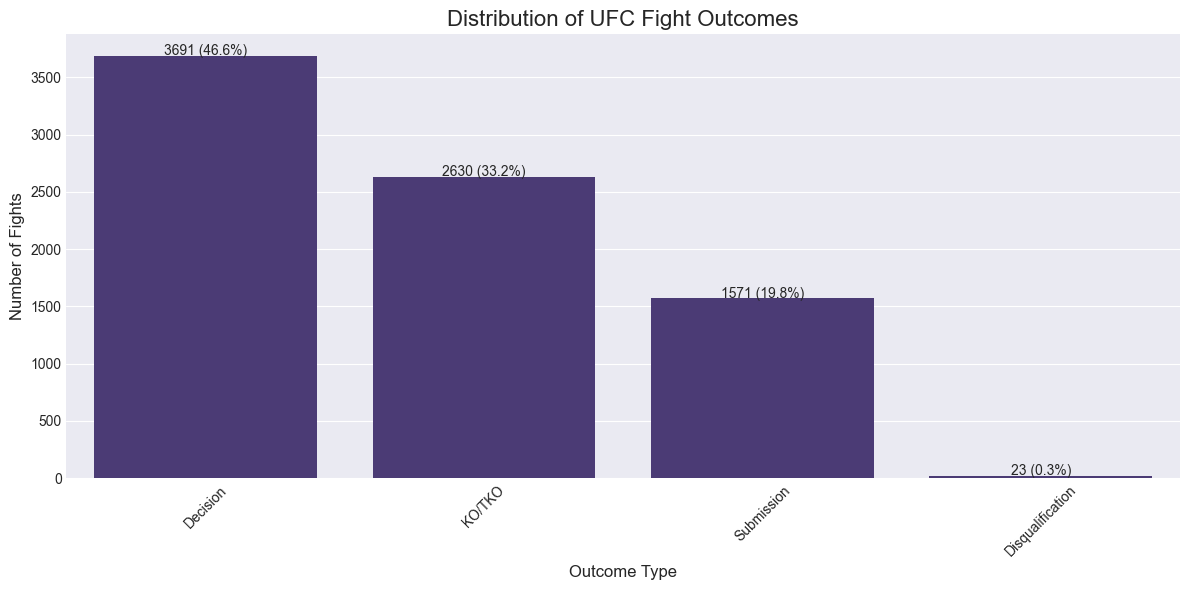

In [7]:
# Clean the method column for better categorization
def categorize_method(method_str):
    if pd.isna(method_str):
        return "Unknown"
    method_str = method_str.strip().lower()
    if 'ko' in method_str or 'tko' in method_str or 'knock' in method_str:
        return "KO/TKO"
    elif 'sub' in method_str or 'tap' in method_str or 'choke' in method_str:
        return "Submission"
    elif 'dec' in method_str or 'decision' in method_str:
        return "Decision"
    elif 'no contest' in method_str or 'nc' in method_str:
        return "No Contest"
    elif 'dq' in method_str or 'disqual' in method_str:
        return "Disqualification"
    else:
        return "Other"

fights_df['outcome_category'] = fights_df['method'].apply(categorize_method)

# Plot the distribution of fight outcomes
plt.figure(figsize=(12, 6))
outcome_counts = fights_df['outcome_category'].value_counts()
ax = sns.barplot(x=outcome_counts.index, y=outcome_counts.values)
plt.title('Distribution of UFC Fight Outcomes', fontsize=16)
plt.xlabel('Outcome Type', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.xticks(rotation=45)

# Add percentage labels
total = len(fights_df)
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 5, f"{v} ({v/total:.1%})", ha='center')

plt.tight_layout()
plt.show()

### 3.2 Round Analysis

Let's examine in which rounds fights tend to finish.

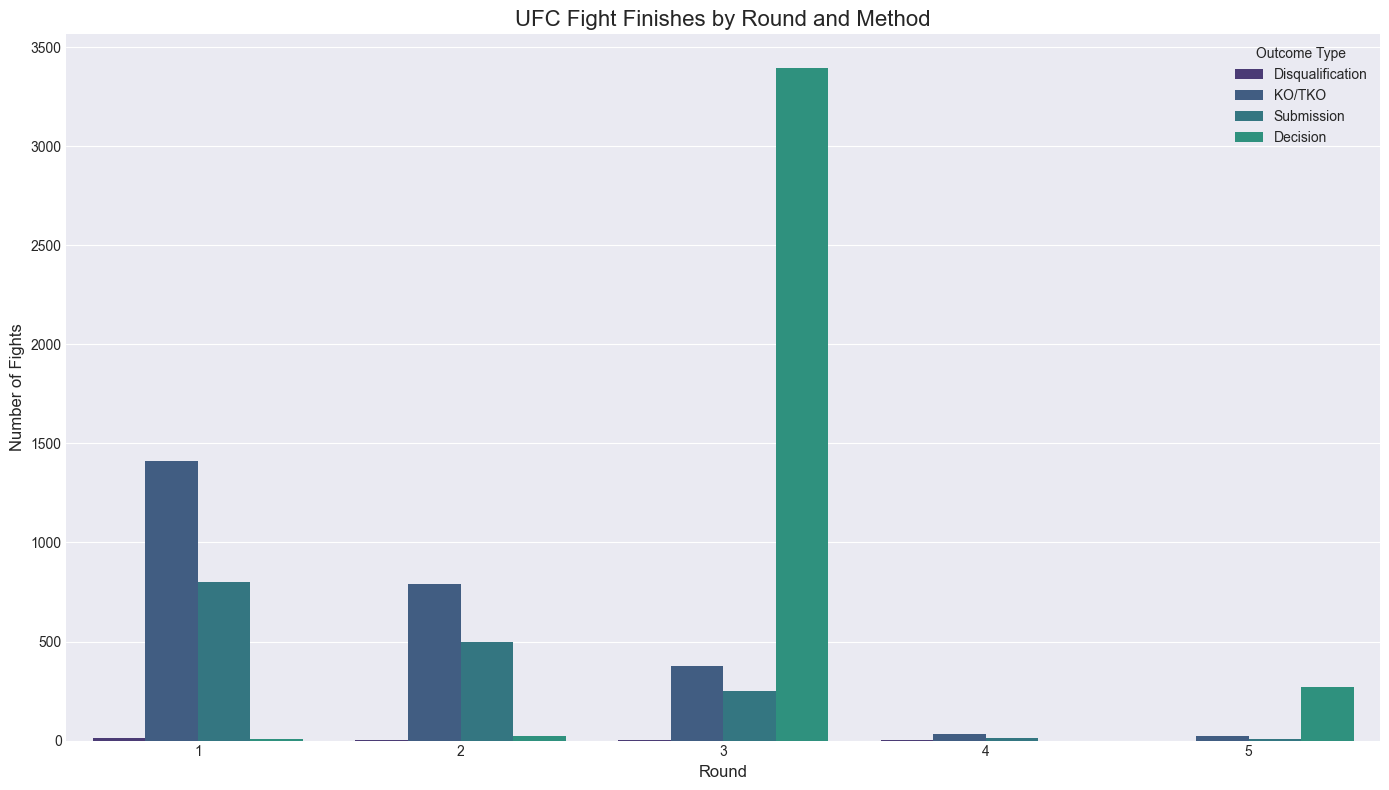

<Figure size 1400x800 with 0 Axes>

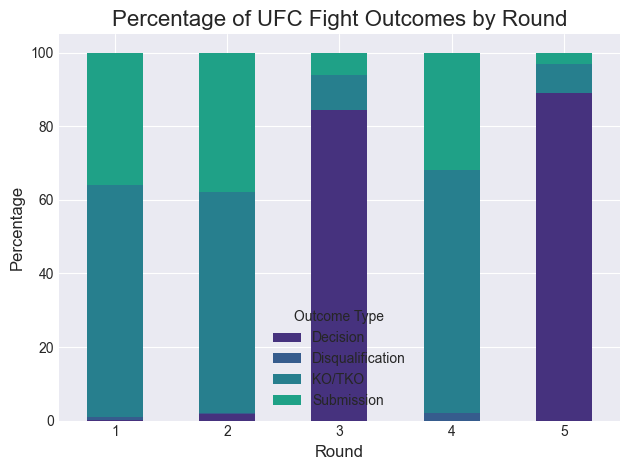

In [8]:
# Convert round to numeric
fights_df['round'] = pd.to_numeric(fights_df['round'], errors='coerce')

# Plot round distribution by outcome type
plt.figure(figsize=(14, 8))
sns.countplot(data=fights_df, x='round', hue='outcome_category')
plt.title('UFC Fight Finishes by Round and Method', fontsize=16)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.legend(title='Outcome Type')

plt.tight_layout()
plt.show()

# Calculate percentage of finishes by round
round_pct = fights_df.groupby('round')['outcome_category'].value_counts(normalize=True).unstack()
round_pct = round_pct.fillna(0) * 100

# Plot percentage of finishes by round
plt.figure(figsize=(14, 8))
round_pct.plot(kind='bar', stacked=True)
plt.title('Percentage of UFC Fight Outcomes by Round', fontsize=16)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Outcome Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3 Striking Statistics Analysis

Let's analyze the relationship between striking statistics and fight outcomes.

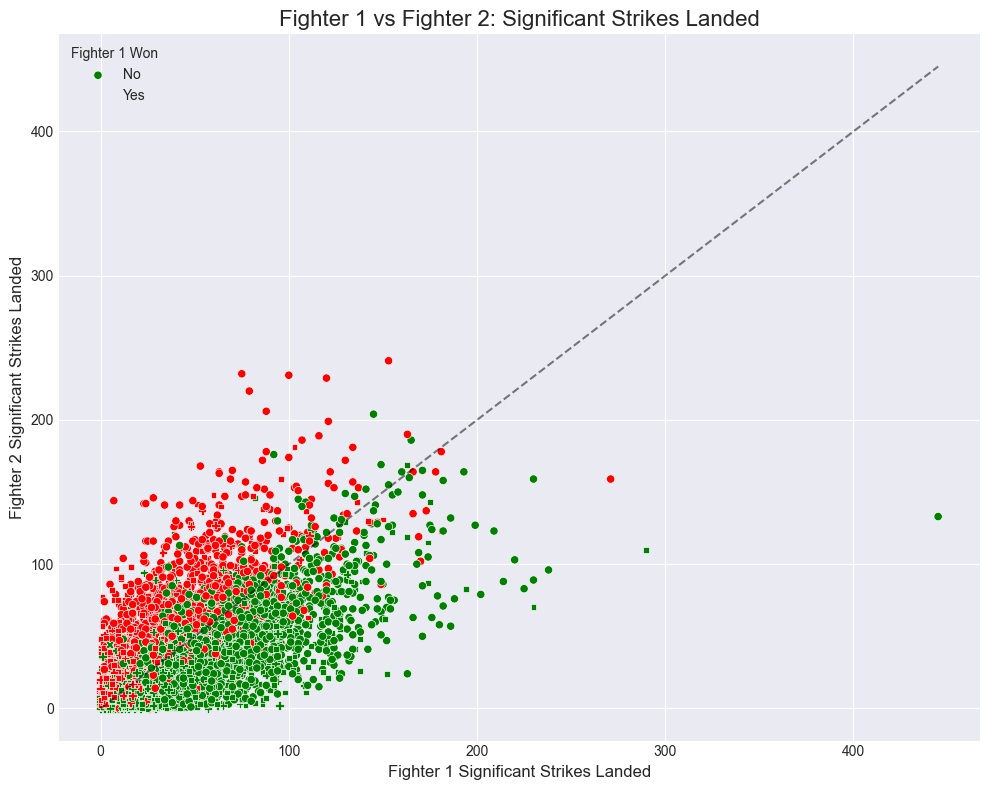

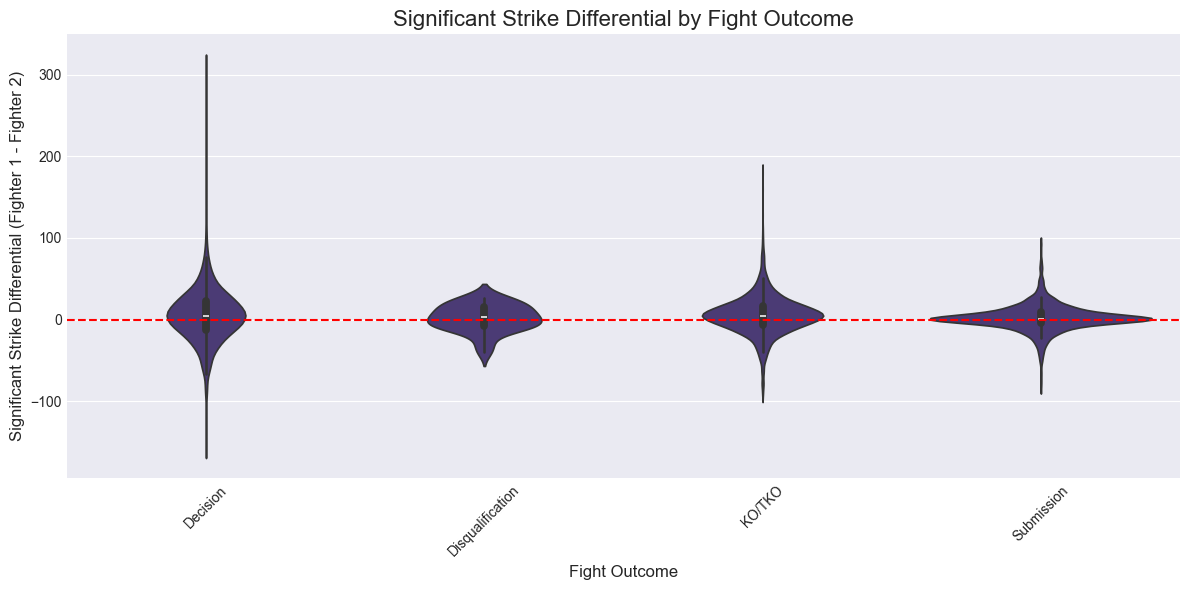

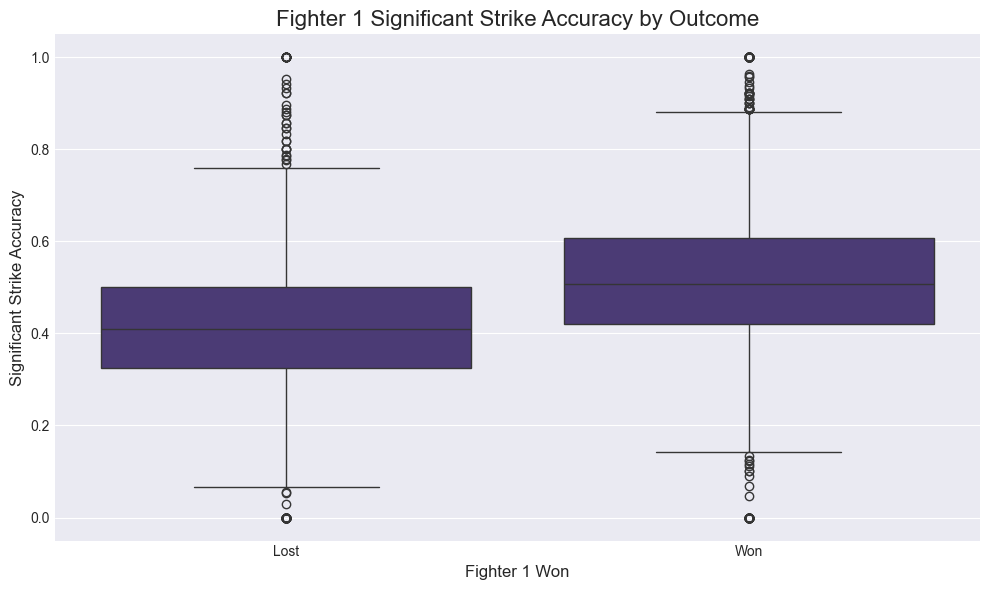

In [9]:
# Create a function to determine if a fighter won
def determine_winner(row, fighter_num):
    if fighter_num == 1:
        return 1 if row['win_loss_1'] == 'W' else 0
    else:
        return 1 if row['win_loss_2'] == 'W' else 0

# Add winner flags
fights_df['fighter_1_won'] = fights_df.apply(lambda row: determine_winner(row, 1), axis=1)
fights_df['fighter_2_won'] = fights_df.apply(lambda row: determine_winner(row, 2), axis=1)

# Calculate striking differential
fights_df['sig_strike_diff'] = fights_df['sig_str_landed_1'] - fights_df['sig_str_landed_2']
fights_df['total_strike_diff'] = fights_df['total_str_landed_1'] - fights_df['total_str_landed_2']

# Create a scatterplot of significant strikes landed vs. fight outcome
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='sig_str_landed_1', 
    y='sig_str_landed_2', 
    hue='fighter_1_won',
    style='outcome_category',
    palette={1: 'green', 0: 'red'},
    data=fights_df
)

# Add a diagonal line for reference (equal strikes)
max_strikes = max(fights_df['sig_str_landed_1'].max(), fights_df['sig_str_landed_2'].max())
plt.plot([0, max_strikes], [0, max_strikes], 'k--', alpha=0.5)

plt.title('Fighter 1 vs Fighter 2: Significant Strikes Landed', fontsize=16)
plt.xlabel('Fighter 1 Significant Strikes Landed', fontsize=12)
plt.ylabel('Fighter 2 Significant Strikes Landed', fontsize=12)
plt.legend(title='Fighter 1 Won', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Create a violin plot of significant strike differential by outcome
plt.figure(figsize=(12, 6))
sns.violinplot(x='outcome_category', y='sig_strike_diff', data=fights_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Significant Strike Differential by Fight Outcome', fontsize=16)
plt.xlabel('Fight Outcome', fontsize=12)
plt.ylabel('Significant Strike Differential (Fighter 1 - Fighter 2)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate strike accuracy relationship to victory
plt.figure(figsize=(10, 6))
sns.boxplot(x='fighter_1_won', y='sig_str_accuracy_1', data=fights_df)
plt.title('Fighter 1 Significant Strike Accuracy by Outcome', fontsize=16)
plt.xlabel('Fighter 1 Won', fontsize=12)
plt.ylabel('Significant Strike Accuracy', fontsize=12)
plt.xticks([0, 1], ['Lost', 'Won'])
plt.tight_layout()
plt.show()


### 3.4 Knockout Analysis

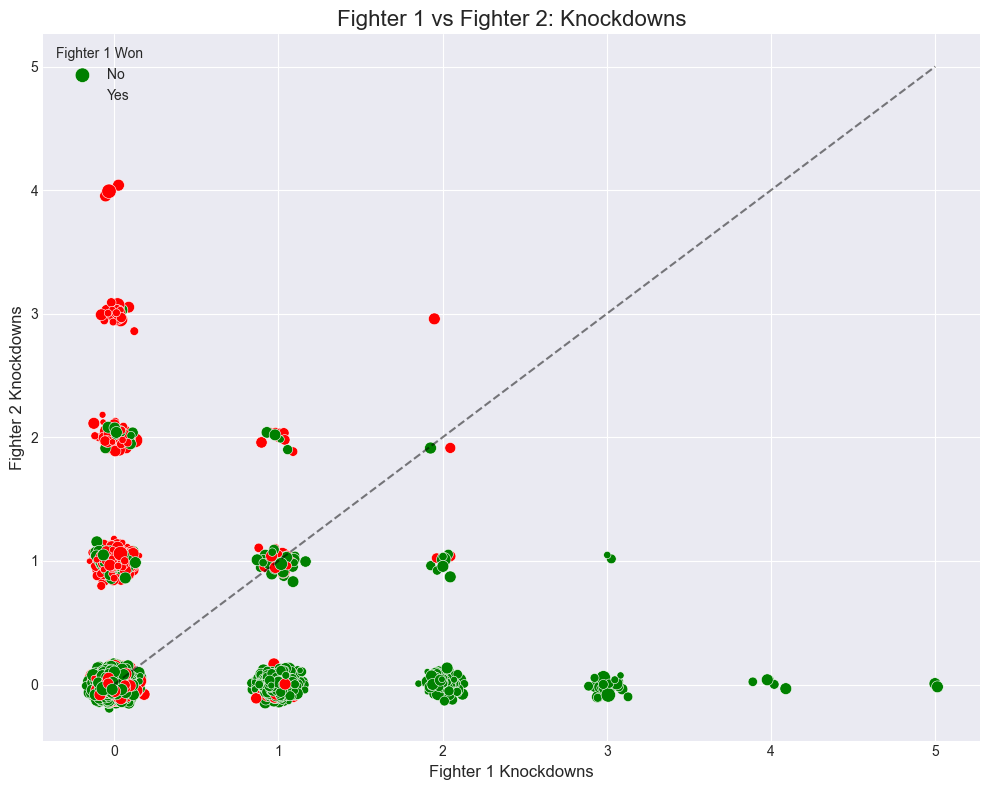

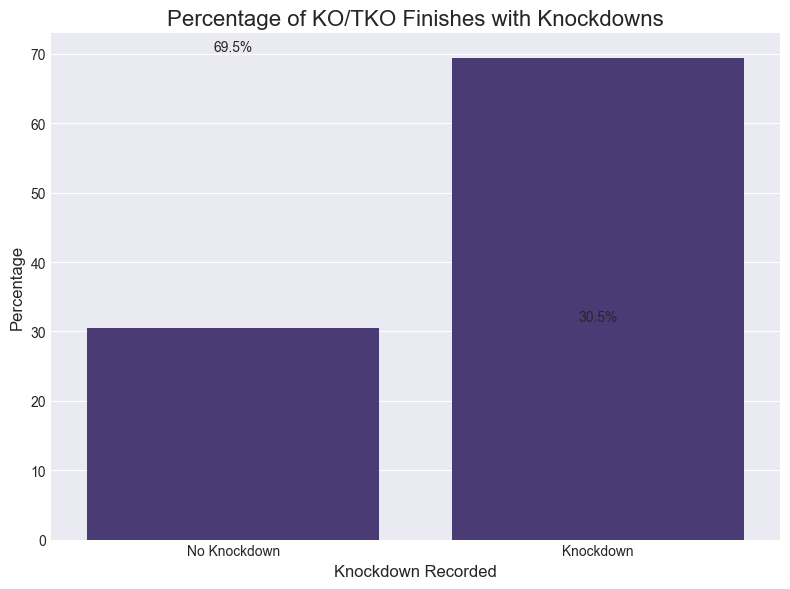

In [10]:
# Create a scatterplot of knockdowns vs. fight outcome
plt.figure(figsize=(10, 8))
# Jitter the points to avoid overlapping
fights_df['kd_1_jitter'] = fights_df['kd_1'] + np.random.normal(0, 0.05, len(fights_df))
fights_df['kd_2_jitter'] = fights_df['kd_2'] + np.random.normal(0, 0.05, len(fights_df))

sns.scatterplot(
    x='kd_1_jitter', 
    y='kd_2_jitter', 
    hue='fighter_1_won',
    size='total_fight_time_seconds',
    sizes=(20, 200),
    palette={1: 'green', 0: 'red'},
    data=fights_df
)

# Add a diagonal line for reference (equal knockdowns)
max_kd = max(fights_df['kd_1'].max(), fights_df['kd_2'].max())
plt.plot([0, max_kd], [0, max_kd], 'k--', alpha=0.5)

plt.title('Fighter 1 vs Fighter 2: Knockdowns', fontsize=16)
plt.xlabel('Fighter 1 Knockdowns', fontsize=12)
plt.ylabel('Fighter 2 Knockdowns', fontsize=12)
plt.legend(title='Fighter 1 Won', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Create a bar chart of knockdown relationship to KO/TKO
ko_tko_fights = fights_df[fights_df['outcome_category'] == 'KO/TKO']
ko_tko_fights['has_knockdown'] = ((ko_tko_fights['kd_1'] > 0) | (ko_tko_fights['kd_2'] > 0)).astype(int)
ko_tko_pct = ko_tko_fights['has_knockdown'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=ko_tko_pct.index, y=ko_tko_pct.values)
plt.title('Percentage of KO/TKO Finishes with Knockdowns', fontsize=16)
plt.xlabel('Knockdown Recorded', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks([0, 1], ['No Knockdown', 'Knockdown'])

# Add percentage labels
for i, v in enumerate(ko_tko_pct.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

### 3.5 Time Series Analysis

<Figure size 1400x800 with 0 Axes>

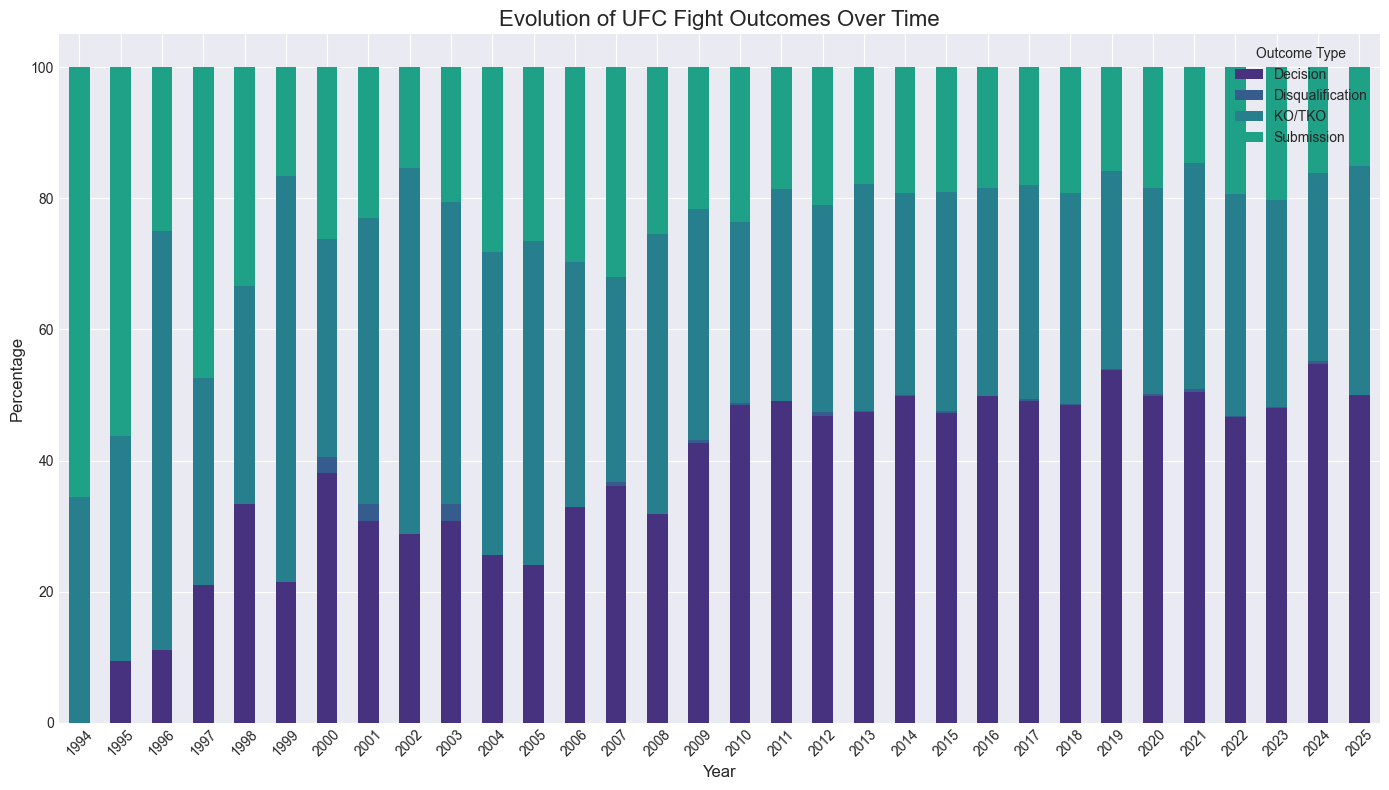

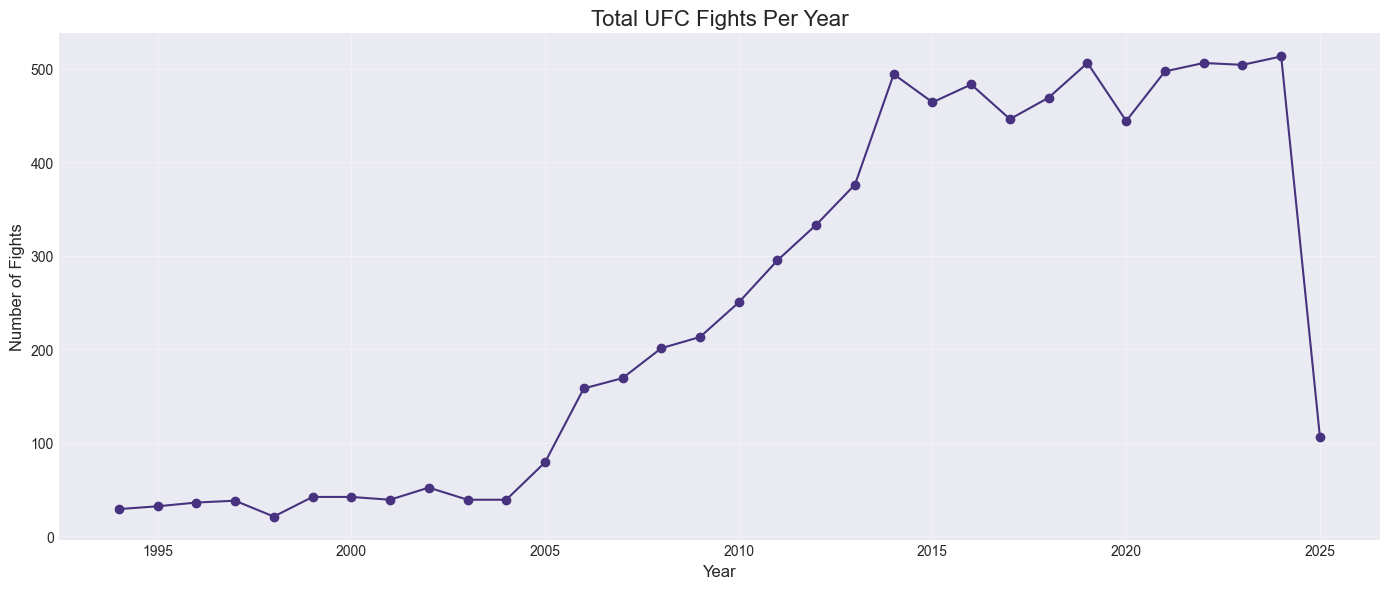

In [11]:
# Group fights by year and count outcomes
fights_df['year'] = fights_df['date'].dt.year
yearly_outcome = fights_df.groupby(['year', 'outcome_category']).size().unstack().fillna(0)

# Calculate percentage of each outcome by year
yearly_pct = yearly_outcome.div(yearly_outcome.sum(axis=1), axis=0) * 100

# Plot the evolution of fight outcomes over time
plt.figure(figsize=(14, 8))
yearly_pct.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Evolution of UFC Fight Outcomes Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Outcome Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the evolution of total fights over time
plt.figure(figsize=(14, 6))
yearly_total = yearly_outcome.sum(axis=1)
yearly_total.plot(kind='line', marker='o')
plt.title('Total UFC Fights Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Fight Duration Analysis

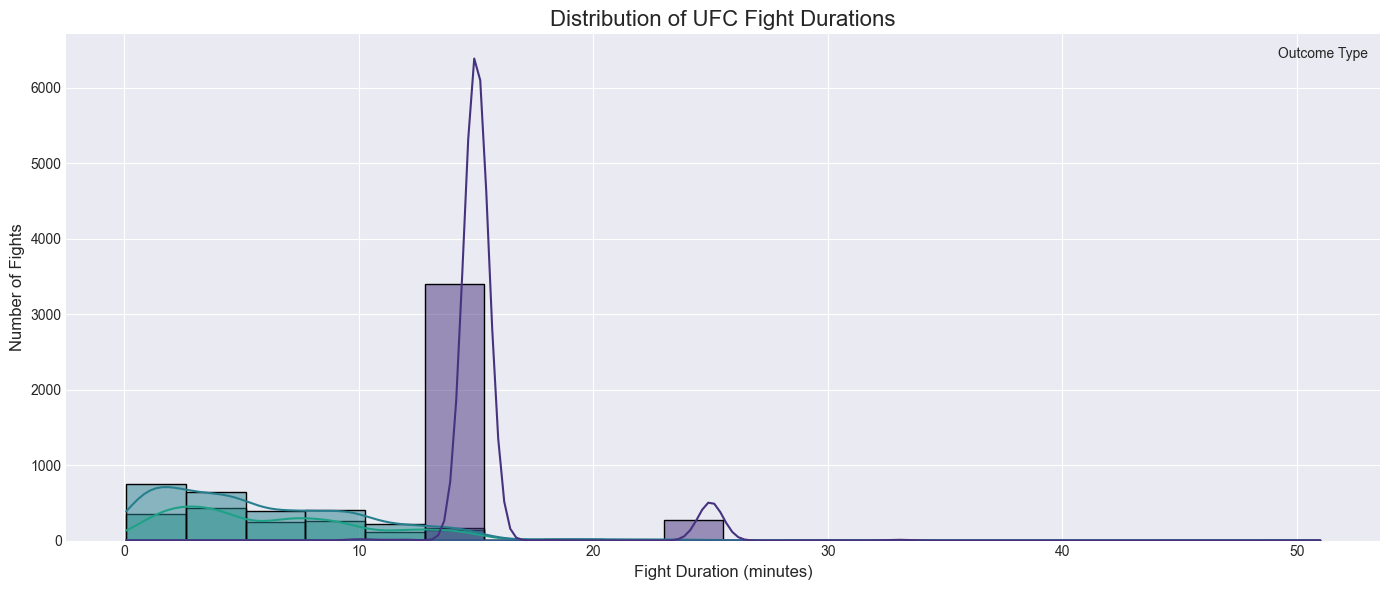

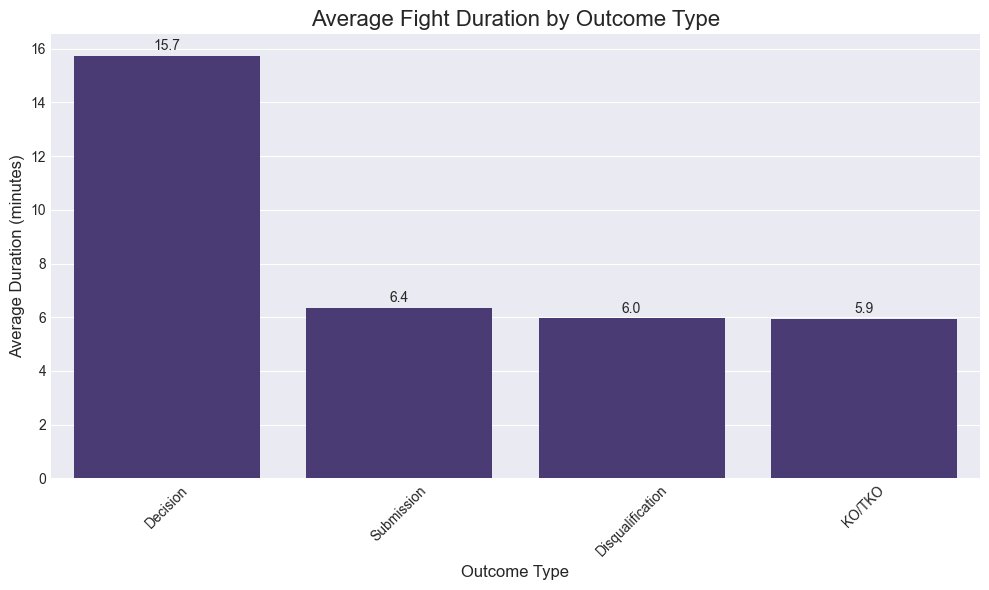

In [12]:
# Convert fight duration to minutes for easier interpretation
fights_df['total_fight_time_minutes'] = fights_df['total_fight_time_seconds'] / 60

# Plot the distribution of fight durations
plt.figure(figsize=(14, 6))
sns.histplot(data=fights_df, x='total_fight_time_minutes', hue='outcome_category', bins=20, kde=True)
plt.title('Distribution of UFC Fight Durations', fontsize=16)
plt.xlabel('Fight Duration (minutes)', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.legend(title='Outcome Type')
plt.tight_layout()
plt.show()

# Calculate average fight duration by outcome
avg_duration = fights_df.groupby('outcome_category')['total_fight_time_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_duration.index, y=avg_duration.values)
plt.title('Average Fight Duration by Outcome Type', fontsize=16)
plt.xlabel('Outcome Type', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)
plt.xticks(rotation=45)

# Add duration labels
for i, v in enumerate(avg_duration.values):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

### 3.7 Fighter Performance Analysis

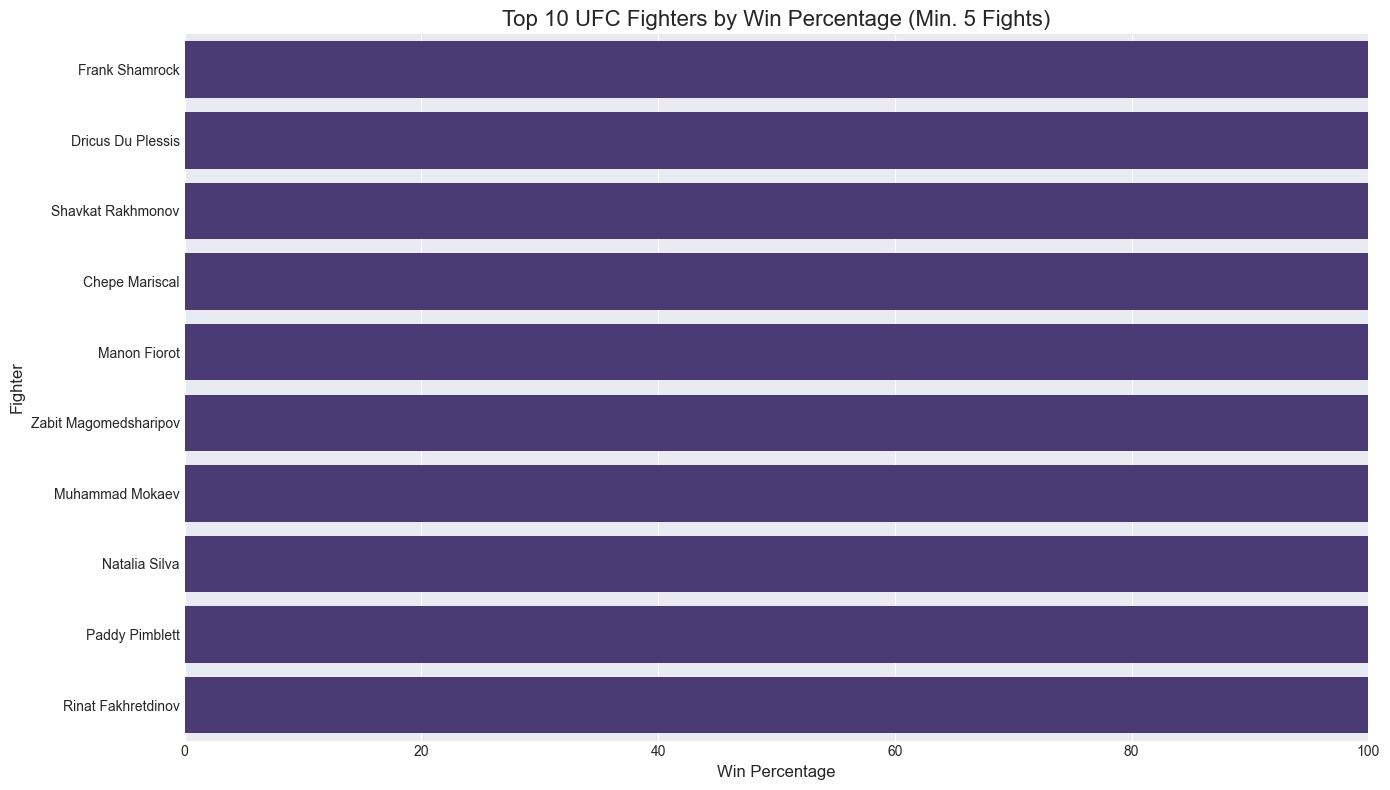

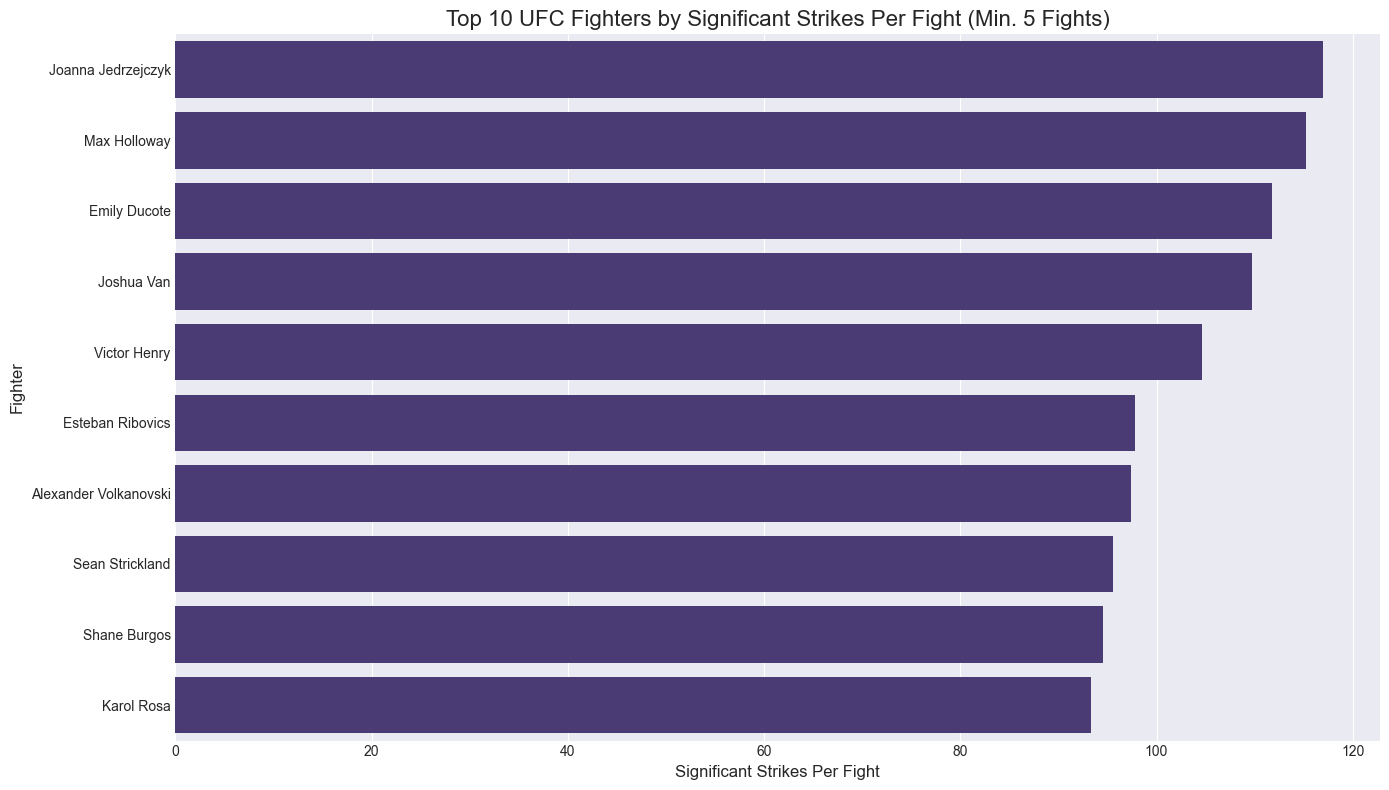

In [13]:
# Create a new dataframe with fighter stats
fighter_stats = pd.DataFrame()

# Collect fighter 1 stats
f1_stats = fights_df[['name_1', 'fighter_1_won', 'sig_str_landed_1', 'sig_str_attempted_1', 
                      'total_str_landed_1', 'kd_1', 'sig_str_accuracy_1']]
f1_stats.columns = ['fighter', 'won', 'sig_strikes_landed', 'sig_strikes_attempted', 
                   'total_strikes_landed', 'knockdowns', 'sig_strike_accuracy']

# Collect fighter 2 stats
f2_stats = fights_df[['name_2', 'fighter_2_won', 'sig_str_landed_2', 'sig_str_attempted_2', 
                      'total_str_landed_2', 'kd_2', 'sig_str_accuracy_2']]
f2_stats.columns = ['fighter', 'won', 'sig_strikes_landed', 'sig_strikes_attempted', 
                   'total_strikes_landed', 'knockdowns', 'sig_strike_accuracy']

# Combine the stats
fighter_stats = pd.concat([f1_stats, f2_stats], ignore_index=True)

# Group by fighter and aggregate stats
fighter_summary = fighter_stats.groupby('fighter').agg(
    fights=('won', 'count'),
    wins=('won', 'sum'),
    sig_strikes_per_fight=('sig_strikes_landed', 'mean'),
    total_strikes_per_fight=('total_strikes_landed', 'mean'),
    knockdowns_per_fight=('knockdowns', 'mean'),
    avg_sig_strike_accuracy=('sig_strike_accuracy', 'mean')
).reset_index()

# Calculate win percentage
fighter_summary['win_pct'] = (fighter_summary['wins'] / fighter_summary['fights']) * 100

# Filter for fighters with at least 5 fights
active_fighters = fighter_summary[fighter_summary['fights'] >= 5].sort_values('win_pct', ascending=False)

# Plot top 10 fighters by win percentage
plt.figure(figsize=(14, 8))
sns.barplot(x='win_pct', y='fighter', data=active_fighters.head(10))
plt.title('Top 10 UFC Fighters by Win Percentage (Min. 5 Fights)', fontsize=16)
plt.xlabel('Win Percentage', fontsize=12)
plt.ylabel('Fighter', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot top 10 fighters by significant strikes per fight
plt.figure(figsize=(14, 8))
top_strikers = active_fighters.sort_values('sig_strikes_per_fight', ascending=False).head(10)
sns.barplot(x='sig_strikes_per_fight', y='fighter', data=top_strikers)
plt.title('Top 10 UFC Fighters by Significant Strikes Per Fight (Min. 5 Fights)', fontsize=16)
plt.xlabel('Significant Strikes Per Fight', fontsize=12)
plt.ylabel('Fighter', fontsize=12)
plt.tight_layout()
plt.show()

### 3.8 Geographic Analysis

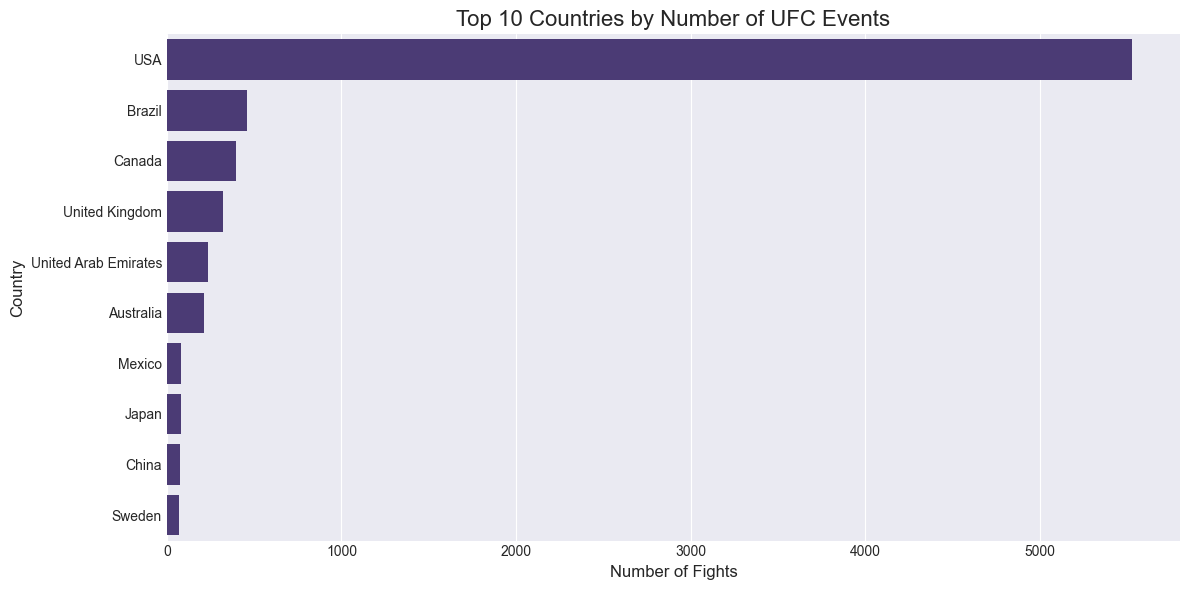

In [14]:
# Clean and extract location data
def extract_country(location_str):
    if pd.isna(location_str):
        return "Unknown"
    location_str = location_str.strip()
    # Extract country (usually the last part after a comma)
    if ',' in location_str:
        return location_str.split(',')[-1].strip()
    return location_str

fights_df['country'] = fights_df['location'].apply(extract_country)

# Count fights by country
country_counts = fights_df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Countries by Number of UFC Events', fontsize=16)
plt.xlabel('Number of Fights', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### 3.9 Correlation Analysis

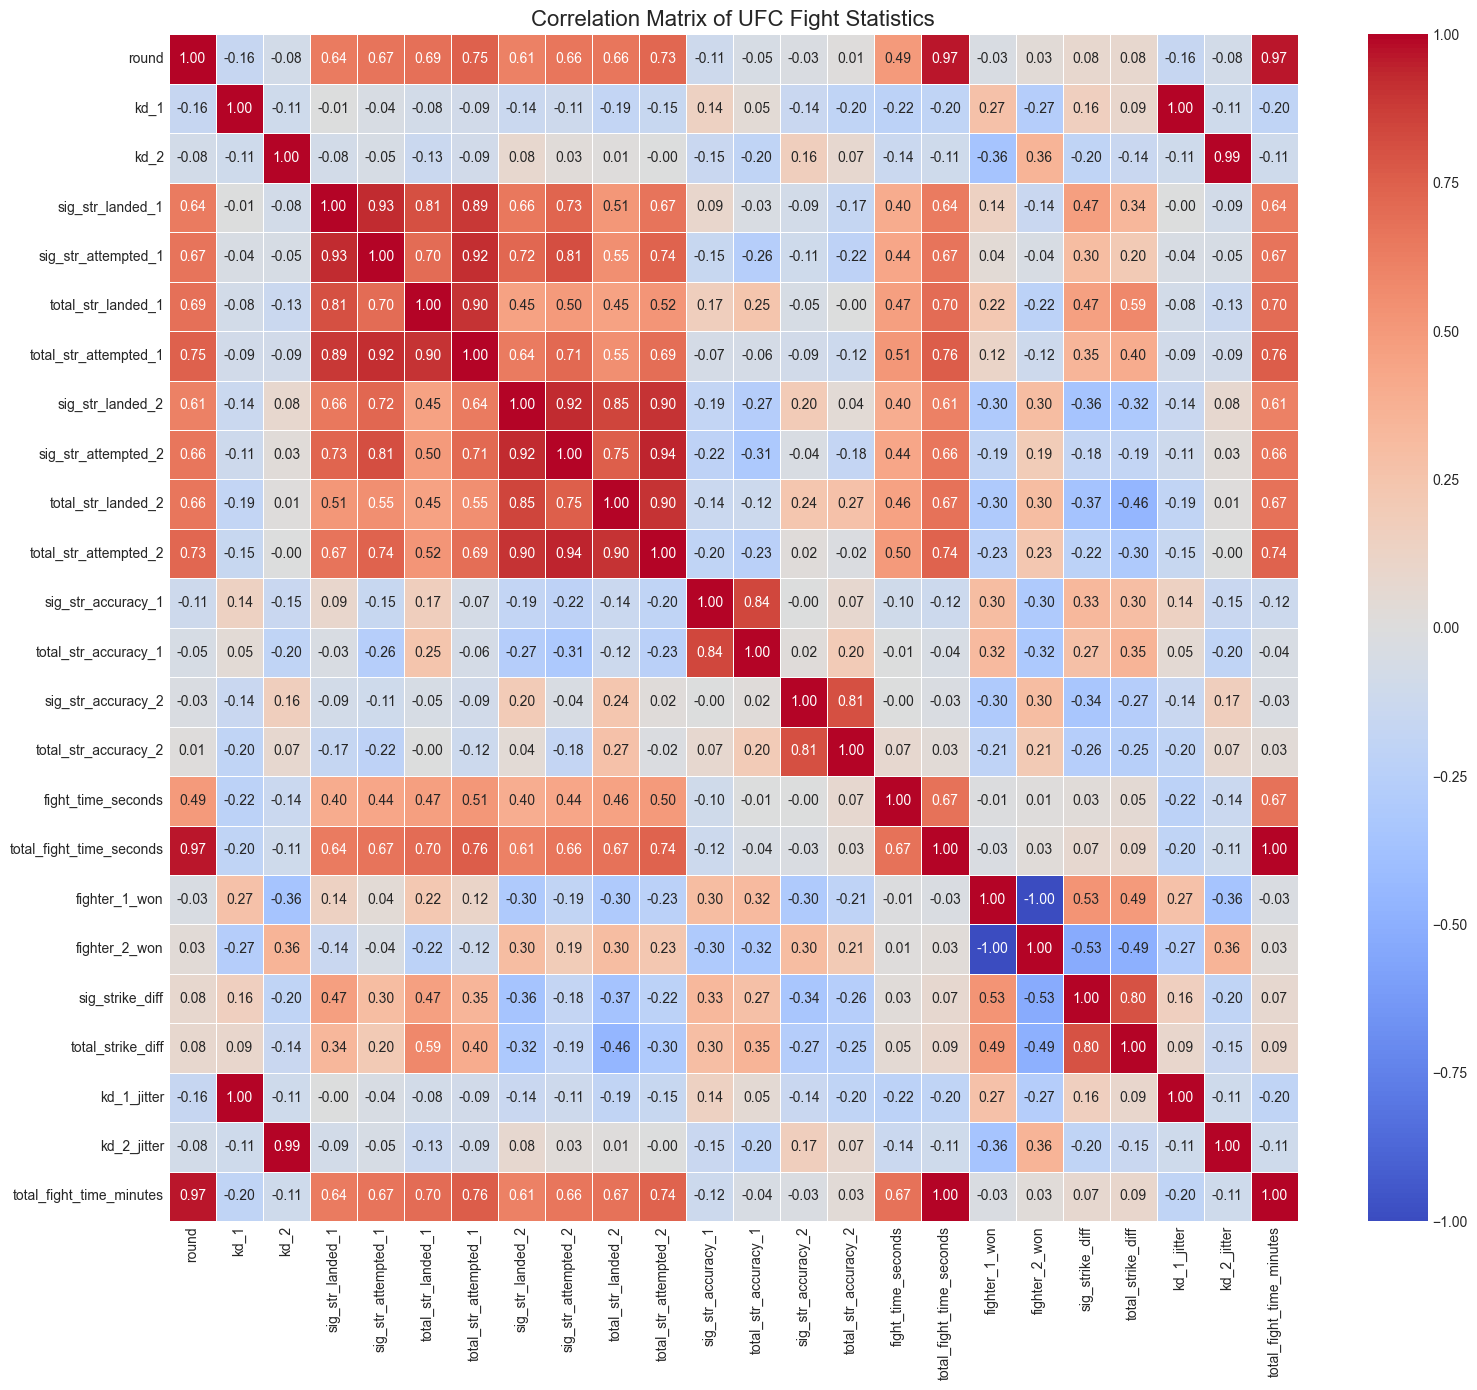

In [15]:
# Calculate correlation matrix for numeric columns
numeric_df = fights_df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of UFC Fight Statistics', fontsize=16)
plt.tight_layout()
plt.show()

### 3.10 Conclusion and Summary

UFC Fight Data Analysis Summary:
Total fights analyzed: 7915
Date range: 1994-03-11 to 2025-03-15
Most common outcome: Decision (46.6%)
Average fight duration: 10.60 minutes


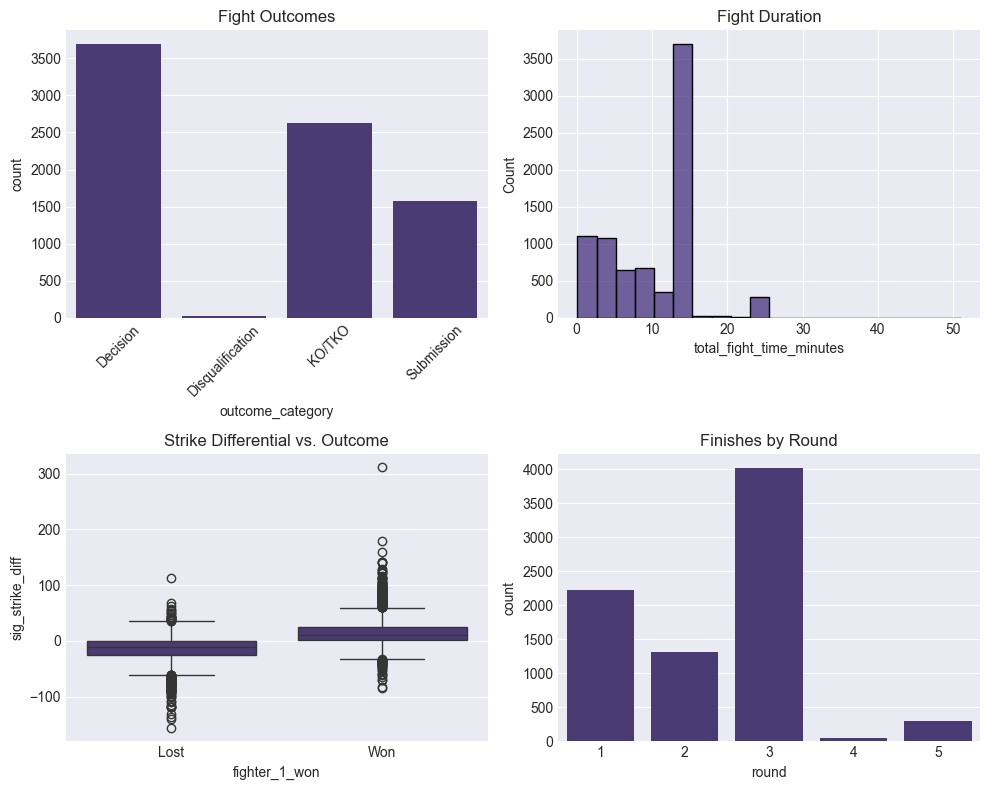

In [16]:
# Print summary statistics
print("UFC Fight Data Analysis Summary:")
print(f"Total fights analyzed: {len(fights_df)}")
print(f"Date range: {fights_df['date'].min().strftime('%Y-%m-%d')} to {fights_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Most common outcome: {fights_df['outcome_category'].value_counts().index[0]} ({fights_df['outcome_category'].value_counts(normalize=True)[0]:.1%})")
print(f"Average fight duration: {fights_df['total_fight_time_minutes'].mean():.2f} minutes")

# Create a summary plot
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
sns.countplot(data=fights_df, x='outcome_category')
plt.title('Fight Outcomes')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sns.histplot(data=fights_df, x='total_fight_time_minutes', bins=20)
plt.title('Fight Duration')

plt.subplot(2, 2, 3)
sns.boxplot(data=fights_df, x='fighter_1_won', y='sig_strike_diff')
plt.title('Strike Differential vs. Outcome')
plt.xticks([0, 1], ['Lost', 'Won'])

plt.subplot(2, 2, 4)
sns.countplot(data=fights_df, x='round')
plt.title('Finishes by Round')

plt.tight_layout()
plt.show()

In [17]:
# Save the final analysis DataFrame
fights_df.to_csv(os.path.join(save_path, "analyzed_fight_details.csv"), index=False)
print("Analysis complete. Final dataset saved to:", os.path.join(save_path, "analyzed_fight_details.csv"))

Analysis complete. Final dataset saved to: Data\analyzed_fight_details.csv
